# 2. 使用Transformers框架实现训练-Trainer与TrainingArguments的使用

## 2.1. Transformers的训练框架

### (1) Trainer与TrainingArguments

- TrainingArguments负责设置参数：
    - 主要设置的参数分成如下几大类：
        - **训练模型的输出路径**。
        - **训练轮数与批次大小**（Training Duration and Batch Size）。
        - **学习率与调度器**（Learning Rate & Scheduler）
        - **优化器**（Optimizer）
        - **正则化与训练稳定性**（Regularization & Training Stability）
        - **混合精度训练**（Mixed Precision Training）
        - 梯度监测点（Gradient Checkpointing）
        - 编译（Compilation）
        - 内核（Kernels）
        - 额外优化（Additional Optimizations）
        - 日志与监控训练（Logging & Monitoring Training）
        - 日志（Logging）
        - 实验追踪集成（Experiment Tracking Integration）
        - **评估**（Evaluation）
        - **指标或者度量计算**（Metrics Computation）
        - 检测点与保存（Checkpointing & Saving）
        - HuggingFace集成（Hugging Face Hub Integration）
        - 最好模型跟踪（Best Model Tracking）
        - **恢复训练**（Resuming Training）
        - 可复现性（Reproducibility）
        - 硬件配置（Hardware Configuration）
        - 加速配置（Accelerate Configuration）
        - 批次数据集（Dataloader）
        - 分布式数据并行（DDP：DistributedDataParallel）
        - 全分片数据并行（FSDP：Fully Sharded Data Parallel）

- Trainer负责执行训练，其构造器参数如下：

```python
 def __init__(
    self,
    model: PreTrainedModel | nn.Module | None = None,  # 需要训练的模型
    args: TrainingArguments | None = None,    # TrainingArguments训练参数设置对象
    data_collator: DataCollator | None = None,   # 数据协作器（在生成Dataloader的时候需要）
    train_dataset: "Dataset | IterableDataset | datasets.Dataset | None" = None,  # 训练数据集
    eval_dataset: "Dataset | dict[str, Dataset] | datasets.Dataset | None" = None,  # 评估数据集
    processing_class: PreTrainedTokenizerBase | BaseImageProcessor | FeatureExtractionMixin | ProcessorMixin | None = None,   # 处理器器类
    model_init: Callable[..., PreTrainedModel] | None = None,   # 模型初始化回调函数
    compute_loss_func: Callable | None = None,      # 损失计算函数
    compute_metrics: Callable[[EvalPrediction], dict] | None = None,  # 计算度量或者指标
    callbacks: list[TrainerCallback] | None = None,   # 训练回调函数
    optimizers: tuple[torch.optim.Optimizer | None, torch.optim.lr_scheduler.LambdaLR | None] = (None, None), # 优化器与调度器
    optimizer_cls_and_kwargs: tuple[type[torch.optim.Optimizer], dict[str, Any]] | None = None,  # 优化器类
    preprocess_logits_for_metrics: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None = None, # 一个函数，用于在每次评估步骤中缓存 logits 之前对其进行预处理。该函数必须接收两个张量（logits 和 labels），并返回按需处理后的 logits。此函数所做的修改将反映在 compute_metrics 接收到的预测结果中。
):
```

### (2) 通过Trainer的条件来确定TrainingArguments参数设置

- 下面我们先使用常用的或者必须的参数选项。

<table>
    <tr>
        <th>Trainer条件</th>
        <th>TrainingArguments参数设置</th>
    </tr>
    <tr>
        <td>模型:model</td>
        <td>指定输出目录，缺省是trainer_output：output_dir</td>
    </tr>
    <tr>
        <td>
            训练数据集：train_dataset<br/>
            验证数据集：eval_dataset<br/>
            批次数据集校对与整理器：data_collator
        </td>
        <td>
            每个设备的批处理大小：per_device_train_batch_size<br/>
            训练轮次：num_train_epochs（要执行的总训练轮数）或者max_steps（总训练步数，也是训练的批数，该参数优先）
        </td>
    </tr>
    <tr>
        <td>优化器：optimizers或者optimizer_cls_and_kwargs</td>
        <td>
            学习率：learning_rate<br/>
            学习率调度器类型：lr_scheduler_type<br/>
            学习调度器参数：lr_scheduler_kwargs<br/>
            学习率热身步数：warmup_steps（学习率从0到学习率逐步到达的步数）<br>
            <hr/>
            优化器名字：optim<br>
            优化器参数：optim_args<br>
            权重参数惩罚系数：weight_decay<br>
            调整误差（整除数为0的时候使用）：adam_epsilon 
        </td>
    </tr>
    <tr>
        <td>
            其他：<br/>
            处理器器类：processing_class<br/>
            模型初始化调用：model_init<br/>
            计算损失：compute_loss_func<br/>
            计算评价指标与度量：compute_metrics<br>
            输出预处理：preprocess_logits_for_metrics
        </td>
        <td>
            其他：<br/>
            混合精度训练：bf16，fp16，tf32<br/>
            日志输出策略：logging_strategy（"no"，"epoch"，"steps"）<br/>
            日志输出级别：log_level（"debug", "info", "warning", "error", "critical", or "passive"）<br/>
            进度显示：disable_tqdm<br/>
            <hr/>
            评估策略：eval_strategy（"no"，"epoch"，"steps"）<br/>
            评估频率：eval_steps<br/>
            <hr/>
            保存内容：save_only_model<br/>
            保存策略：save_strategy<br/>
            保存频率：save_steps<br/> 
            <hr/>
            硬件使用：use_cpu
        </td>
    </tr>
</table>

## 2.2. 使用Trainer训练的列子

- 我们使用前面yolo的例子，通过对照加深理解模型训练的条件，过程与步骤，以及训练过程中的重要数据处理。

In [1]:
import os
import torch
import torchvision
import transformers

### (1) 准备数据集

In [2]:
# 继承CocoDetection，实现一些定制处理的数据集
class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, ds_folder, processor, train=True):
        # 标注文件
        ann_file = os.path.join(ds_folder, "train_data.json" if train else "val_data.json")
        # 图像目录
        img_dir = os.path.join(ds_folder, "train" if train else "val")
        super(CocoDetection, self).__init__(img_dir, ann_file)
        self.processor = processor

    def __getitem__(self, idx):
        # 读取PIL image和标签target（默认格式），我们需要进行转换（比如转换为张量）
        img, target = super(CocoDetection, self).__getitem__(idx)
        
        # 转换图像与标签格式 (重点是把标签转换为训练模式支持的格式DETR, 同时缩放，标准化图像与标签
        # 把我们需要访问的图像索引，映射到对应的图像编号，保证能正确访问到文件
        image_id = self.ids[idx]  
        target = {'image_id': image_id, 'annotations': target}
         # 全部转换为张量，而且只获取训练需要的数据。
        encoding = self.processor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # 返回的数据按照torch的格式有批次维度，去掉批次维度
        target = encoding["labels"][0] # 使用下标的方式去掉维度
        return pixel_values, target
        
# 创建批次数据集
# processor = transformers.YolosImageProcessor.from_pretrained("F:/03Models/yolos-tiny", size=512, max_size=1333)
processor = transformers.YolosImageProcessor.from_pretrained("F:/03Models/yolos-tiny")
train_dataset = CocoDetection(ds_folder='F:/04Datasets/balloon/', processor=processor)
val_dataset = CocoDetection(ds_folder='F:/04Datasets/balloon/', processor=processor, train=False)

def collate_fn(batch):
    # 去除图像，进行对齐
    pixel_values = [item[0] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")
    # 取出标签
    labels = [item[1] for item in batch]
    # 重新返回处理过的数据集
    batch = {}
    batch['pixel_values'] = encoding['pixel_values']
    batch['labels'] = labels
    return batch

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


### (2) 准备模型

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# 类别数量改变，其分类器也会被强制改变，原来的矩阵权重就加载不进去，这个部分的权重会被从头训练。
model = transformers.YolosForObjectDetection.from_pretrained(
    "F:/03Models/yolos-tiny", 
    num_labels=len(train_dataset.coco.cats),  # 类别数量（我们这类是1）
    ignore_mismatched_sizes=True
)  # 注意：加载的模型可能在cpu上（这个模型就是在cpu上）
model.to(device)

W0322 10:19:51.181000 18396 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Some weights of YolosForObjectDetection were not initialized from the model checkpoint at F:/03Models/yolos-tiny and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 192]) in the checkpoint and torch.Size([2, 192]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


YolosForObjectDetection(
  (vit): YolosModel(
    (embeddings): YolosEmbeddings(
      (patch_embeddings): YolosPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (interpolation): InterpolateInitialPositionEmbeddings()
    )
    (encoder): YolosEncoder(
      (layer): ModuleList(
        (0-11): 12 x YolosLayer(
          (attention): YolosAttention(
            (attention): YolosSelfAttention(
              (query): Linear(in_features=192, out_features=192, bias=True)
              (key): Linear(in_features=192, out_features=192, bias=True)
              (value): Linear(in_features=192, out_features=192, bias=True)
            )
            (output): YolosSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): YolosIntermediate(
            (dense

### (3) 优化器准备

In [4]:
epochs = 1000
learning_rate = 2.5e-5   # 学习率
weight_decay=1e-4   # 权重惩罚系数（也称权重衰减系数）
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=learning_rate,
    weight_decay=weight_decay
)

### (4) 准备训练参数(TrainingArguments对象)

In [5]:
args = transformers.TrainingArguments(
    output_dir="./tmp",
    per_device_train_batch_size=10,
    num_train_epochs=epochs,
    warmup_steps=4,
    # logging_strategy="epoch",
    logging_steps=250, 
    log_level="info",
    use_cpu=False,
    save_steps=500  # 保存checkpoint是的频率。
)

### (5) 准备训练器并开始训练

In [6]:
trainer = transformers.Trainer(
    model=model,
    args=args,
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    optimizers=(optimizer, None)   # 可以让Trainer自己选择优化器
)

In [7]:
trainer.train()

***** Running training *****
  Num examples = 61
  Num Epochs = 1,000
  Instantaneous batch size per device = 10
  Total train batch size (w. parallel, distributed & accumulation) = 10
  Gradient Accumulation steps = 1
  Total optimization steps = 7,000
  Number of trainable parameters = 6,471,366


Step,Training Loss
250,0.619600
500,0.284700
750,0.248000
1000,0.222700
1250,0.215900
1500,0.209000
1750,0.186400
2000,0.171300
2250,0.170300
2500,0.153500


Saving model checkpoint to ./tmp\checkpoint-500
Configuration saved in ./tmp\checkpoint-500\config.json
Model weights saved in ./tmp\checkpoint-500\model.safetensors
Saving model checkpoint to ./tmp\checkpoint-1000
Configuration saved in ./tmp\checkpoint-1000\config.json
Model weights saved in ./tmp\checkpoint-1000\model.safetensors
Saving model checkpoint to ./tmp\checkpoint-1500
Configuration saved in ./tmp\checkpoint-1500\config.json
Model weights saved in ./tmp\checkpoint-1500\model.safetensors
Saving model checkpoint to ./tmp\checkpoint-2000
Configuration saved in ./tmp\checkpoint-2000\config.json
Model weights saved in ./tmp\checkpoint-2000\model.safetensors
Saving model checkpoint to ./tmp\checkpoint-2500
Configuration saved in ./tmp\checkpoint-2500\config.json
Model weights saved in ./tmp\checkpoint-2500\model.safetensors
Saving model checkpoint to ./tmp\checkpoint-3000
Configuration saved in ./tmp\checkpoint-3000\config.json
Model weights saved in ./tmp\checkpoint-3000\model.s

TrainOutput(global_step=7000, training_loss=0.1398032124383109, metrics={'train_runtime': 7292.92, 'train_samples_per_second': 8.364, 'train_steps_per_second': 0.96, 'total_flos': 4.0082992484080804e+18, 'train_loss': 0.1398032124383109, 'epoch': 1000.0})

### (6) 使用训练好的模型进行推理

0.8732759952545166, LABEL_0, (211, 155, 333, 345)
1.0, LABEL_0, (210, 152, 344, 330)
0.999997615814209, LABEL_0, (314, 344, 438, 490)
0.9999279975891113, LABEL_0, (150, 486, 278, 570)
0.9999998807907104, LABEL_0, (58, 358, 223, 513)
0.9294722676277161, LABEL_0, (315, 338, 441, 481)
0.999594509601593, LABEL_0, (267, 323, 309, 441)
0.9999998807907104, LABEL_0, (144, 252, 291, 439)
0.9999996423721313, LABEL_0, (318, 344, 441, 494)


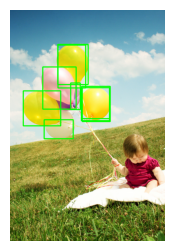

In [8]:
import torch
import matplotlib.pyplot as plt
import PIL
img_file = "F:/04Datasets/balloon/val/3825919971_93fb1ec581_b.jpg"
# 1. 预处理preprocess====================================
# 1.1. 加载图像
image = PIL.Image.open(img_file)   # 打开图像
image = PIL.ImageOps.exif_transpose(image)  # 根据图像的EXIF方向信息，自动旋转图像，使其以正确的方向显示。
image = image.convert("RGB")  # 把图像转换为RGB像素格式
# 1.2. 调用processor进行图像处理
inputs = processor(images=[image], return_tensors="pt")  
# YolosImageProcessorFast返回具有两个字段（pixel_mask，pixel_values）的字典pixel_mask是图像补齐的掩码，1表示真实像素，0表示padding像素
# YolosImageProcessor返回具只有一个字段（pixel_values）的字典
# 1.3. 获取图像大小（侦测目标后，结果要复原成原图像大小
target_size = torch.IntTensor([[image.height, image.width]])
# 2. 推理forward=========================================
# 2.1. 调用模型进行推理
inputs["pixel_values"] = inputs["pixel_values"].to(device)
with torch.no_grad():
    model_outputs = model(**inputs)  # 把字典展开为关键字参数形式,模型输出为YolosObjectDetectionOutput对象
# model_outputs = outputs.__class__({"target_size": target_size, **model_outputs})  # 在输出的结果中注入一个字段（与字典的注入方式不同）

# 3. 后处理postprocess===================================
## 3.1. 调用processor进行后处理（阈值是过滤概率较低的侦测目标）
post_outputs = processor.post_process_object_detection(model_outputs, threshold=0.5, target_sizes=target_size)
## 3.2. 对后处理的数据进行格式转换。其中boxes需要转换为int。这样容易绘制。
post_output = post_outputs[0] # 一张图像的处理
scores = post_output["scores"].tolist()
labels = post_output["labels"].tolist()
boxes = post_output["boxes"].to(int).tolist()

# 转换格式后替换原来输出
post_output["scores"] = scores
post_output["labels"] = [model.config.id2label[label] for label in labels]
post_output["boxes"] = [{"xmin":xmin, "ymin":ymin, "xmax": xmax, "ymax":ymax} for xmin, ymin, xmax, ymax in boxes]

# 3.3. 把输出还原成官方格式（目标转换为列表，每个元素就是一个侦测的目标，每个目标使用字典表示score，label，box）
keys = ["score", "label", "box"]
results = [dict(zip(keys, vals)) for vals in zip(post_output["scores"], post_output["labels"], post_output["boxes"])]

# 4. 可视化#####################################
def visual(imgfile, objects):
    import matplotlib.pyplot as plt
    import cv2
    img = cv2.imread(imgfile, cv2.IMREAD_COLOR_RGB)
    for a_object in objects:
        score = a_object["score"]
        label = a_object["label"]
        xmin = a_object["box"]["xmin"]
        ymin = a_object["box"]["ymin"]
        xmax = a_object["box"]["xmax"]
        ymax = a_object["box"]["ymax"]
        print(F"{score}, {label}, ({xmin}, {ymin}, {xmax}, {ymax})")
        cv2.rectangle(img, pt1=(xmin, ymin), pt2=(xmax, ymax), color=(0, 255, 0), thickness=3)
    plt.figure(figsize=(4, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.savefig('tmp/result.png')
visual(img_file, results)

-----

# 说明

- Trainer不保存YolosImageProcessor图像处理器，需要用户自己在训练完成后，手工保存。除手工保存外，Trainer也提供解决方案：
    - 继承Trainer，重写保存相关的函数，实现自动保存。
    - 使用TrainerCallback，在构建Trainer对象时，通过设置参数完成。

----